
# GVH Diagonal Cubic 0.2.22 — Static Spherical Solution and PPN Derivation
## Solution statique sphérique, développement de champ faible et extraction de \(\gamma_{\rm GVH}\) et \(\beta_{\rm GVH}\)

**Auteur : Charlemagne O Laurince**

---

## Objectif

Le notebook 0.2.21 a construit une interface expérimentale :

\[
\gamma_{\rm eff}=1+\epsilon_D\gamma_D,
\qquad
\beta_{\rm eff}=1+\epsilon_D\beta_D.
\]

Mais les coefficients \(\gamma_D\) et \(\beta_D\) n’étaient pas encore reliés à une solution statique du modèle.

Cette version étudie une métrique sphérique générale :

\[
ds^2
=
-A(r)c^2dt^2
+
B(r)dr^2
+
C(r)r^2d\Omega^2,
\]

puis :

1. reproduit exactement la limite de Schwarzschild ;
2. transforme Schwarzschild en coordonnées isotropes ;
3. extrait les coefficients PPN de référence ;
4. introduit une famille de corrections GVH statiques ;
5. relie les coefficients métriques aux paramètres \(\gamma_{\rm GVH}\) et \(\beta_{\rm GVH}\) ;
6. impose les contraintes de Cassini, LLR et du redshift ;
7. distingue une **prédiction dérivée** d’une **paramétrisation candidate**.

---

## Limite scientifique essentielle

Une solution statique unique ne peut être dérivée sans une action covariante GVH entièrement fixée et ses équations de champ complètes.

Le notebook produit donc :

- une dérivation exacte de la référence GR ;
- une dérivation PPN exacte pour une famille métrique GVH paramétrée ;
- un système d’équations que la future solution de champ devra satisfaire.

Il ne prétend pas encore que les coefficients libres sont les prédictions définitives de GVH.


In [1]:

import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

sp.init_printing()
np.set_printoptions(precision=12, suppress=True)

print("Environnement chargé.")


Environnement chargé.



# 1. Métrique statique sphérique générale

Dans les coordonnées d’aire :

\[
ds^2
=
-A(r)c^2dt^2
+
B(r)dr^2
+
r^2
\left(
d\theta^2+\sin^2\theta\,d\phi^2
\right).
\]

Nous adoptons la signature :

\[
(-,+,+,+).
\]


In [2]:

t, r, theta, phi = sp.symbols(
    "t r theta phi",
    real=True
)

c, G, M = sp.symbols(
    "c G M",
    positive=True,
    real=True
)

A = sp.Function("A")(r)
B = sp.Function("B")(r)

coordinates = [t, r, theta, phi]

g = sp.diag(
    -A*c**2,
    B,
    r**2,
    r**2*sp.sin(theta)**2
)

g_inv = sp.simplify(g.inv())

display(g)


⎡  2                           ⎤
⎢-c ⋅A(r)   0    0       0     ⎥
⎢                              ⎥
⎢   0      B(r)  0       0     ⎥
⎢                              ⎥
⎢                 2            ⎥
⎢   0       0    r       0     ⎥
⎢                              ⎥
⎢                     2    2   ⎥
⎣   0       0    0   r ⋅sin (θ)⎦


# 2. Symboles de Christoffel

\[
\Gamma^\mu_{\alpha\beta}
=
\frac12g^{\mu\nu}
\left(
\partial_\alpha g_{\nu\beta}
+
\partial_\beta g_{\nu\alpha}
-
\partial_\nu g_{\alpha\beta}
\right).
\]


In [3]:

def christoffel_symbols(metric, coords):
    inverse = sp.simplify(metric.inv())
    n = metric.shape[0]

    Gamma = [
        [
            [
                sp.simplify(
                    sp.Rational(1,2)
                    * sum(
                        inverse[mu,nu]
                        * (
                            sp.diff(metric[nu,beta],coords[alpha])
                            + sp.diff(metric[nu,alpha],coords[beta])
                            - sp.diff(metric[alpha,beta],coords[nu])
                        )
                        for nu in range(n)
                    )
                )
                for beta in range(n)
            ]
            for alpha in range(n)
        ]
        for mu in range(n)
    ]

    return Gamma


Gamma = christoffel_symbols(
    g,
    coordinates
)

nonzero_Gamma = []

for mu in range(4):
    for alpha in range(4):
        for beta in range(4):
            value = sp.simplify(
                Gamma[mu][alpha][beta]
            )

            if value != 0:
                nonzero_Gamma.append({
                    "mu":mu,
                    "alpha":alpha,
                    "beta":beta,
                    "expression":value
                })

print("Nombre de composantes non nulles :",len(nonzero_Gamma))
pd.DataFrame(nonzero_Gamma).head(20)


Nombre de composantes non nulles : 13


,mu,alpha,beta,expression
0,0,0,1,"Derivative(A(r), r)/(2*A(r))"
1,0,1,0,"Derivative(A(r), r)/(2*A(r))"
2,1,0,0,"c**2*Derivative(A(r), r)/(2*B(r))"
3,1,1,1,"Derivative(B(r), r)/(2*B(r))"
4,1,2,2,-r/B(r)
5,1,3,3,-r*sin(theta)**2/B(r)
6,2,1,2,1/r
7,2,2,1,1/r
8,2,3,3,-sin(2*theta)/2
9,3,1,3,1/r



# 3. Tenseur de Ricci et équations du vide

\[
R_{\mu\nu}
=
\partial_\alpha\Gamma^\alpha_{\mu\nu}
-
\partial_\nu\Gamma^\alpha_{\mu\alpha}
+
\Gamma^\alpha_{\alpha\beta}
\Gamma^\beta_{\mu\nu}
-
\Gamma^\alpha_{\nu\beta}
\Gamma^\beta_{\mu\alpha}.
\]

Dans le vide de la relativité générale :

\[
R_{\mu\nu}=0.
\]


In [4]:

def ricci_tensor(Gamma, coords):
    n = len(coords)
    Ricci = sp.MutableDenseMatrix.zeros(n,n)

    for mu in range(n):
        for nu in range(n):
            expression = sp.Integer(0)

            for alpha in range(n):
                expression += sp.diff(
                    Gamma[alpha][mu][nu],
                    coords[alpha]
                )

                expression -= sp.diff(
                    Gamma[alpha][mu][alpha],
                    coords[nu]
                )

                for beta in range(n):
                    expression += (
                        Gamma[alpha][alpha][beta]
                        * Gamma[beta][mu][nu]
                    )

                    expression -= (
                        Gamma[alpha][nu][beta]
                        * Gamma[beta][mu][alpha]
                    )

            Ricci[mu,nu] = sp.simplify(expression)

    return sp.Matrix(Ricci)


Ricci = ricci_tensor(
    Gamma,
    coordinates
)

print("R_tt =")
display(sp.factor(Ricci[0,0]))

print("R_rr =")
display(sp.factor(Ricci[1,1]))

print("R_theta_theta =")
display(sp.factor(Ricci[2,2]))


R_tt =


   ⎛               2                                                      2    ↪
 2 ⎜              d                  d        d                 ⎛d       ⎞     ↪
c ⋅⎜2⋅r⋅A(r)⋅B(r)⋅───(A(r)) - r⋅A(r)⋅──(A(r))⋅──(B(r)) - r⋅B(r)⋅⎜──(A(r))⎟  +  ↪
   ⎜                2                dr       dr                ⎝dr      ⎠     ↪
   ⎝              dr                                                           ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                    2                          ↪
                                          4⋅r⋅A(r)⋅B (r)                       ↪

↪                     ⎞
↪             d       ⎟
↪ 4⋅A(r)⋅B(r)⋅──(A(r))⎟
↪             dr      ⎟
↪                     ⎠
↪ ─────────────────────
↪                      
↪                      

R_rr =


 ⎛               2                                                      2      ↪
 ⎜              d                  d        d                 ⎛d       ⎞       ↪
-⎜2⋅r⋅A(r)⋅B(r)⋅───(A(r)) - r⋅A(r)⋅──(A(r))⋅──(B(r)) - r⋅B(r)⋅⎜──(A(r))⎟  - 4⋅ ↪
 ⎜                2                dr       dr                ⎝dr      ⎠       ↪
 ⎝              dr                                                             ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                             2                                 ↪
                                        4⋅r⋅A (r)⋅B(r)                         ↪

↪               ⎞ 
↪  2    d       ⎟ 
↪ A (r)⋅──(B(r))⎟ 
↪       dr      ⎟ 
↪               ⎠ 
↪ ────────────────
↪                 
↪                 

R_theta_theta =


       d                 d                  2                 
r⋅A(r)⋅──(B(r)) - r⋅B(r)⋅──(A(r)) + 2⋅A(r)⋅B (r) - 2⋅A(r)⋅B(r)
       dr                dr                                   
──────────────────────────────────────────────────────────────
                                 2                            
                         2⋅A(r)⋅B (r)                         


# 4. Solution de Schwarzschild

Nous définissons :

\[
r_s
=
\frac{2GM}{c^2},
\]

\[
A_{\rm S}(r)
=
1-\frac{r_s}{r},
\]

\[
B_{\rm S}(r)
=
\left(
1-\frac{r_s}{r}
\right)^{-1}.
\]

Cette solution doit annuler le tenseur de Ricci dans le vide.


In [5]:

r_s = sp.simplify(
    2*G*M/c**2
)

A_S = sp.simplify(
    1-r_s/r
)

B_S = sp.simplify(
    1/A_S
)

schwarzschild_subs = {
    A:A_S,
    B:B_S,
    sp.diff(A,r):sp.diff(A_S,r),
    sp.diff(A,r,2):sp.diff(A_S,r,2),
    sp.diff(B,r):sp.diff(B_S,r),
    sp.diff(B,r,2):sp.diff(B_S,r,2)
}

Ricci_S = sp.simplify(
    Ricci.subs(schwarzschild_subs)
)

display(Ricci_S)


⎡0  0  0  0⎤
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎣0  0  0  0⎦


# 5. Coordonnée isotrope

Le formalisme PPN standard utilise des coordonnées spatiales isotropes :

\[
ds^2
=
-\mathcal A(\rho)c^2dt^2
+
\mathcal B(\rho)
\left(
d\rho^2+\rho^2d\Omega^2
\right).
\]

La transformation Schwarzschild est :

\[
r
=
\rho
\left(
1+\frac{GM}{2\rho c^2}
\right)^2.
\]

En définissant :

\[
u
=
\frac{GM}{\rho c^2},
\]

on obtient :

\[
\mathcal A_{\rm S}
=
\left(
\frac{1-u/2}{1+u/2}
\right)^2,
\]

\[
\mathcal B_{\rm S}
=
\left(
1+\frac{u}{2}
\right)^4.
\]


In [6]:

rho, u = sp.symbols(
    "rho u",
    positive=True,
    real=True
)

A_iso_S = sp.simplify(
    ((1-u/2)/(1+u/2))**2
)

B_iso_S = sp.simplify(
    (1+u/2)**4
)

display(A_iso_S)
display(B_iso_S)


       2
(u - 2) 
────────
       2
(u + 2) 

       4
(u + 2) 
────────
   16   


# 6. Développement de champ faible de Schwarzschild

Le développement PPN attendu est :

\[
g_{tt}
=
-1+2u-2u^2+\mathcal O(u^3),
\]

\[
g_{ij}
=
\left(
1+2u+\frac32u^2+\cdots
\right)\delta_{ij}.
\]

Cela correspond à :

\[
\gamma_{\rm GR}=1,
\qquad
\beta_{\rm GR}=1.
\]


In [7]:

A_iso_series = sp.series(
    A_iso_S,
    u,
    0,
    4
).removeO()

B_iso_series = sp.series(
    B_iso_S,
    u,
    0,
    4
).removeO()

gtt_iso_series = sp.expand(
    -A_iso_series
)

display(gtt_iso_series)
display(B_iso_series)


   3                 
3⋅u       2          
──── - 2⋅u  + 2⋅u - 1
 2                   

 3      2          
u    3⋅u           
── + ──── + 2⋅u + 1
2     2            


# 7. Famille statique GVH en coordonnées isotropes

Nous introduisons la famille :

\[
g_{tt}^{\rm GVH}
=
-1
+
2a_1u
-
2a_2u^2
+
a_3u^3,
\]

\[
g_{ij}^{\rm GVH}
=
\left(
1
+
2b_1u
+
b_2u^2
+
b_3u^3
\right)
\delta_{ij}.
\]

La limite newtonienne impose :

\[
a_1=1.
\]

Le formalisme PPN identifie :

\[
\beta_{\rm GVH}
=
\frac{a_2}{a_1^2},
\]

\[
\gamma_{\rm GVH}
=
\frac{b_1}{a_1}.
\]

Si \(a_1=1\) :

\[
\beta_{\rm GVH}=a_2,
\qquad
\gamma_{\rm GVH}=b_1.
\]


In [8]:

a1, a2, a3 = sp.symbols(
    "a1 a2 a3",
    real=True
)

b1, b2, b3 = sp.symbols(
    "b1 b2 b3",
    real=True
)

gtt_GVH = sp.expand(
    -1
    + 2*a1*u
    - 2*a2*u**2
    + a3*u**3
)

gspace_GVH = sp.expand(
    1
    + 2*b1*u
    + b2*u**2
    + b3*u**3
)

beta_GVH = sp.simplify(
    a2/a1**2
)

gamma_GVH = sp.simplify(
    b1/a1
)

display(gtt_GVH)
display(gspace_GVH)
display(beta_GVH)
display(gamma_GVH)


               2       3    
2⋅a₁⋅u - 2⋅a₂⋅u  + a₃⋅u  - 1

             2       3    
2⋅b₁⋅u + b₂⋅u  + b₃⋅u  + 1

a₂ 
───
  2
a₁ 

b₁
──
a₁


# 8. Correspondance avec l’interface de 0.2.21

Le notebook précédent utilisait :

\[
\gamma_{\rm eff}
=
1+\epsilon_D\gamma_D,
\]

\[
\beta_{\rm eff}
=
1+\epsilon_D\beta_D.
\]

Nous identifions maintenant :

\[
\epsilon_D\gamma_D
=
\frac{b_1}{a_1}-1,
\]

\[
\epsilon_D\beta_D
=
\frac{a_2}{a_1^2}-1.
\]

Cette relation convertit les coefficients de la solution statique en paramètres expérimentaux.


In [9]:

epsilon_D, gamma_D, beta_D = sp.symbols(
    "epsilon_D gamma_D beta_D",
    real=True
)

Delta_gamma_static = sp.simplify(
    gamma_GVH-1
)

Delta_beta_static = sp.simplify(
    beta_GVH-1
)

display(Delta_gamma_static)
display(Delta_beta_static)


-a₁ + b₁
────────
   a₁   

     a₂ 
-1 + ───
       2
     a₁ 


# 9. Paramétrisation directement reliée au secteur directionnel

Une famille utile est :

\[
a_1=1+\epsilon_D\alpha_1,
\]

\[
a_2=1+\epsilon_D\alpha_2,
\]

\[
b_1=1+\epsilon_D\sigma_1.
\]

À premier ordre en \(\epsilon_D\) :

\[
\gamma_{\rm GVH}-1
\approx
\epsilon_D
(\sigma_1-\alpha_1),
\]

\[
\beta_{\rm GVH}-1
\approx
\epsilon_D
(\alpha_2-2\alpha_1).
\]

Ainsi :

\[
\gamma_D
=
\sigma_1-\alpha_1,
\]

\[
\beta_D
=
\alpha_2-2\alpha_1
\]

au premier ordre.


In [10]:

alpha1, alpha2, sigma1 = sp.symbols(
    "alpha1 alpha2 sigma1",
    real=True
)

parameterized_subs = {
    a1:1+epsilon_D*alpha1,
    a2:1+epsilon_D*alpha2,
    b1:1+epsilon_D*sigma1
}

Delta_gamma_eps = sp.series(
    Delta_gamma_static.subs(parameterized_subs),
    epsilon_D,
    0,
    2
).removeO()

Delta_beta_eps = sp.series(
    Delta_beta_static.subs(parameterized_subs),
    epsilon_D,
    0,
    2
).removeO()

display(sp.expand(Delta_gamma_eps))
display(sp.expand(Delta_beta_eps))


-α₁⋅ε_D + ε_D⋅σ₁

-2⋅α₁⋅ε_D + α₂⋅ε_D


# 10. Cas strictement spatial sans trace

Le secteur développé dans les notebooks précédents impose initialement :

\[
\bar D_{00}=0.
\]

Une correction statique purement spatiale peut alors donner approximativement :

\[
\alpha_1=0,
\qquad
\alpha_2=0,
\qquad
\sigma_1\neq0.
\]

Dans ce cas :

\[
\beta_{\rm GVH}=1,
\]

\[
\gamma_{\rm GVH}-1
\approx
\epsilon_D\sigma_1.
\]

Cassini devient alors le test principal de champ faible.


In [11]:

pure_spatial_result = {
    "Delta_gamma":sp.simplify(
        Delta_gamma_eps.subs({
            alpha1:0,
            alpha2:0
        })
    ),
    "Delta_beta":sp.simplify(
        Delta_beta_eps.subs({
            alpha1:0,
            alpha2:0
        })
    )
}

pure_spatial_result


{'Delta_gamma': epsilon_D*sigma1, 'Delta_beta': 0}


# 11. Cas conforme universel

Si la correction modifie les secteurs temporel et spatial de façon identique au premier ordre :

\[
\sigma_1=\alpha_1,
\]

alors :

\[
\gamma_{\rm GVH}=1
\]

à premier ordre.

Pour conserver également :

\[
\beta_{\rm GVH}=1,
\]

il faut :

\[
\alpha_2=2\alpha_1.
\]

Cette famille est PPN-dégénérée avec GR à l’ordre étudié, mais peut différer aux ordres supérieurs \(u^3\) ou en champ fort.


In [12]:

ppn_degenerate_conditions = sp.solve(
    [
        sp.expand(
            Delta_gamma_eps/epsilon_D
        ),
        sp.expand(
            Delta_beta_eps/epsilon_D
        )
    ],
    [sigma1,alpha2],
    dict=True
)

ppn_degenerate_conditions


[{α₂: 2⋅α₁, σ₁: α₁}]


# 12. Équation statique candidate du champ directionnel

Sans équations de champ définitives, nous étudions une équation radiale minimale de type Yukawa :

\[
D''(r)
+
\frac{2}{r}D'(r)
-
m_D^2D(r)
=
0
\]

dans le vide.

La solution décroissante est :

\[
D(r)
=
\frac{Q_D}{r}
e^{-m_Dr}.
\]

Cette solution est un **prototype**, pas encore la solution fondamentale de GVH.


In [13]:

D = sp.Function("D")(r)
m_D = sp.symbols(
    "m_D",
    nonnegative=True,
    real=True
)

radial_equation = sp.simplify(
    sp.diff(D,r,2)
    + 2/r*sp.diff(D,r)
    - m_D**2*D
)

display(radial_equation)

Q_D = sp.symbols(
    "Q_D",
    real=True
)

D_yukawa = sp.simplify(
    Q_D*sp.exp(-m_D*r)/r
)

yukawa_residual = sp.simplify(
    radial_equation.subs({
        D:D_yukawa,
        sp.diff(D,r):sp.diff(D_yukawa,r),
        sp.diff(D,r,2):sp.diff(D_yukawa,r,2)
    })
)

display(yukawa_residual)


                            d       
               2          2⋅──(D(r))
     2        d             dr      
- m_D ⋅D(r) + ───(D(r)) + ──────────
                2             r     
              dr                    

0


# 13. Potentiel effectif radial candidat

Nous introduisons une correction dimensionless :

\[
\chi_D(r)
=
q_D
e^{-r/\lambda_D}.
\]

Une famille métrique possible est :

\[
g_{tt}
=
-1
+
2u
-
2u^2
+
\epsilon_tu\chi_D(r),
\]

\[
g_{ij}
=
\left[
1
+
2u
+
\epsilon_su\chi_D(r)
\right]\delta_{ij}.
\]

Les coefficients PPN deviennent dépendants de l’échelle si \(\lambda_D\) est finie.

Une théorie PPN standard strictement locale est récupérée dans la limite où \(\chi_D\) varie lentement sur l’expérience.


In [14]:

q_D, lambda_D = sp.symbols(
    "q_D lambda_D",
    positive=True,
    real=True
)

epsilon_t, epsilon_s = sp.symbols(
    "epsilon_t epsilon_s",
    real=True
)

chi_D = sp.simplify(
    q_D*sp.exp(-r/lambda_D)
)

gtt_yukawa = sp.simplify(
    -1
    + 2*G*M/(r*c**2)
    - 2*(G*M/(r*c**2))**2
    + epsilon_t
    * G*M/(r*c**2)
    * chi_D
)

gspace_yukawa = sp.simplify(
    1
    + 2*G*M/(r*c**2)
    + epsilon_s
    * G*M/(r*c**2)
    * chi_D
)

display(gtt_yukawa)
display(gspace_yukawa)


                        -r             
                        ───            
     2  2               λ_D            
  2⋅G ⋅M    G⋅M⋅εₜ⋅q_D⋅ℯ      2⋅G⋅M    
- ─────── + ─────────────── + ───── - 1
    4  2          2            2       
   c ⋅r          c ⋅r         c ⋅r     

            -r             
            ───            
            λ_D            
G⋅M⋅εₛ⋅q_D⋅ℯ      2⋅G⋅M    
─────────────── + ───── + 1
      2            2       
     c ⋅r         c ⋅r     


# 14. Paramètres PPN effectifs dépendant de \(r\)

Au premier ordre en \(u\), les coefficients effectifs sont :

\[
a_1(r)
=
1+\frac{\epsilon_t}{2}\chi_D(r),
\]

\[
b_1(r)
=
1+\frac{\epsilon_s}{2}\chi_D(r).
\]

Donc :

\[
\gamma_{\rm eff}(r)
=
\frac{
1+\epsilon_s\chi_D(r)/2
}{
1+\epsilon_t\chi_D(r)/2
}.
\]

À premier ordre :

\[
\gamma_{\rm eff}(r)-1
\approx
\frac{
\epsilon_s-\epsilon_t
}{2}
\chi_D(r).
\]


In [15]:

a1_r = sp.simplify(
    1+epsilon_t*chi_D/2
)

b1_r = sp.simplify(
    1+epsilon_s*chi_D/2
)

gamma_r = sp.simplify(
    b1_r/a1_r
)

gamma_r_linear = sp.series(
    gamma_r,
    q_D,
    0,
    2
).removeO()

display(gamma_r)
display(sp.expand(gamma_r_linear))


             r 
            ───
            λ_D
εₛ⋅q_D + 2⋅ℯ   
───────────────
             r 
            ───
            λ_D
εₜ⋅q_D + 2⋅ℯ   

        -r            -r     
        ───           ───    
        λ_D           λ_D    
εₛ⋅q_D⋅ℯ      εₜ⋅q_D⋅ℯ       
─────────── - ─────────── + 1
     2             2         


# 15. Limites expérimentales de travail

Nous reprenons les enveloppes utilisées dans 0.2.21 :

\[
|\gamma-1|
\lesssim
6.7\times10^{-5}
\]

pour l’enveloppe Cassini \(2\sigma\) adoptée, et :

\[
|\beta-1|
\lesssim
3.4\times10^{-4}
\]

pour l’enveloppe LLR historique adoptée.

Ces valeurs sont des benchmarks du pipeline et non une compilation exhaustive de toutes les analyses contemporaines.


In [16]:

gamma_bound = 6.7e-5
beta_bound = 3.4e-4

bounds_df = pd.DataFrame([
    {
        "parameter":"abs(gamma-1)",
        "bound":gamma_bound,
        "benchmark":"Cassini 2-sigma envelope used in 0.2.21"
    },
    {
        "parameter":"abs(beta-1)",
        "bound":beta_bound,
        "benchmark":"LLR historical 2-sigma envelope used in 0.2.21"
    }
])

bounds_df


,parameter,bound,benchmark
0,abs(gamma-1),0.000067,Cassini 2-sigma envelope used in 0.2.21
1,abs(beta-1),0.000340,LLR historical 2-sigma envelope used in 0.2.21



# 16. Contraintes directes sur les coefficients statiques

Avec la normalisation newtonienne :

\[
a_1=1,
\]

on a :

\[
|\gamma_{\rm GVH}-1|
=
|b_1-1|
<
B_\gamma,
\]

\[
|\beta_{\rm GVH}-1|
=
|a_2-1|
<
B_\beta.
\]


In [17]:

def classify_static_coefficients(
    a1_value,
    a2_value,
    b1_value,
    gamma_limit=gamma_bound,
    beta_limit=beta_bound
):
    gamma_value = b1_value/a1_value
    beta_value = a2_value/a1_value**2

    gamma_ok = abs(
        gamma_value-1
    ) <= gamma_limit

    beta_ok = abs(
        beta_value-1
    ) <= beta_limit

    status = (
        "PASS-PPN"
        if gamma_ok and beta_ok
        else "REJECT-PPN"
    )

    return {
        "a1":a1_value,
        "a2":a2_value,
        "b1":b1_value,
        "gamma":gamma_value,
        "beta":beta_value,
        "gamma_ok":gamma_ok,
        "beta_ok":beta_ok,
        "status":status
    }


static_candidates = pd.DataFrame([
    classify_static_coefficients(
        1.0,
        1.0,
        1.0
    ),
    classify_static_coefficients(
        1.0,
        1.0,
        1.0+1e-5
    ),
    classify_static_coefficients(
        1.0,
        1.0+2e-4,
        1.0+2e-5
    ),
    classify_static_coefficients(
        1.0,
        1.01,
        1.01
    )
])

static_candidates


,a1,a2,b1,gamma,beta,gamma_ok,beta_ok,status
0,1.0,1.0000,1.00000,1.00000,1.0000,True,True,PASS-PPN
1,1.0,1.0000,1.00001,1.00001,1.0000,True,True,PASS-PPN
2,1.0,1.0002,1.00002,1.00002,1.0002,True,True,PASS-PPN
3,1.0,1.0100,1.01000,1.01000,1.0100,False,False,REJECT-PPN



# 17. Région admissible dans le plan \((a_2,b_1)\)

Pour \(a_1=1\), la région PPN est centrée sur :

\[
(a_2,b_1)=(1,1).
\]


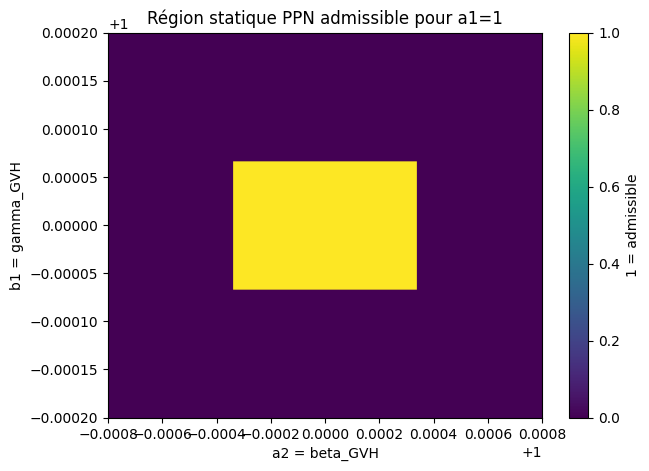

In [18]:

a2_grid = np.linspace(
    1-8e-4,
    1+8e-4,
    600
)

b1_grid = np.linspace(
    1-2e-4,
    1+2e-4,
    600
)

A2, B1 = np.meshgrid(
    a2_grid,
    b1_grid
)

allowed = (
    np.abs(A2-1) <= beta_bound
) & (
    np.abs(B1-1) <= gamma_bound
)

plt.figure(figsize=(7,5))
plt.imshow(
    allowed.astype(float),
    origin="lower",
    extent=[
        a2_grid.min(),
        a2_grid.max(),
        b1_grid.min(),
        b1_grid.max()
    ],
    aspect="auto"
)
plt.xlabel("a2 = beta_GVH")
plt.ylabel("b1 = gamma_GVH")
plt.title("Région statique PPN admissible pour a1=1")
plt.colorbar(label="1 = admissible")
plt.show()



# 18. Contrainte sur une correction Yukawa

Au premier ordre :

\[
|\gamma(r)-1|
\approx
\left|
\frac{\epsilon_s-\epsilon_t}{2}
q_De^{-r/\lambda_D}
\right|.
\]

Cassini impose donc, à l’échelle \(r_{\rm test}\) :

\[
\left|
(\epsilon_s-\epsilon_t)
q_D
e^{-r_{\rm test}/\lambda_D}
\right|
\lesssim
2B_\gamma.
\]


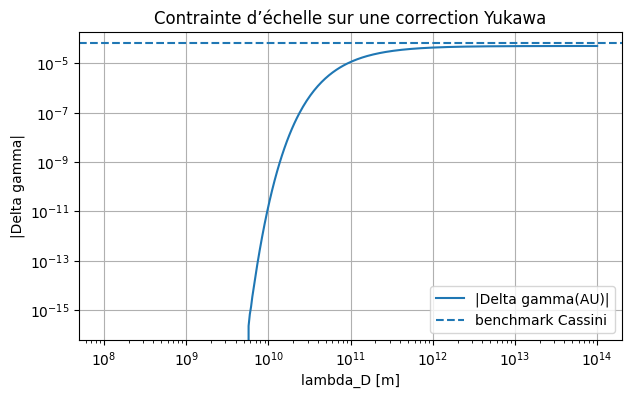

In [19]:

def yukawa_gamma_deviation(
    r_value,
    lambda_value,
    q_value,
    epsilon_spatial,
    epsilon_temporal
):
    chi = q_value*np.exp(
        -r_value/lambda_value
    )

    a1_value = (
        1
        + epsilon_temporal*chi/2
    )

    b1_value = (
        1
        + epsilon_spatial*chi/2
    )

    return (
        b1_value/a1_value-1
    )


AU = 1.495978707e11

lambda_values = np.logspace(
    8,
    14,
    400
)

gamma_deviation_examples = np.array([
    yukawa_gamma_deviation(
        AU,
        lam,
        q_value=1e-4,
        epsilon_spatial=1.0,
        epsilon_temporal=0.0
    )
    for lam in lambda_values
])

plt.figure(figsize=(7,4))
plt.loglog(
    lambda_values,
    np.abs(gamma_deviation_examples),
    label="|Delta gamma(AU)|"
)
plt.axhline(
    gamma_bound,
    linestyle="--",
    label="benchmark Cassini"
)
plt.xlabel("lambda_D [m]")
plt.ylabel("|Delta gamma|")
plt.title("Contrainte d’échelle sur une correction Yukawa")
plt.grid(True)
plt.legend()
plt.show()



# 19. Résolution numérique prototype

Nous intégrons l’équation radiale :

\[
D''+\frac2rD'-m_D^2D=0
\]

avec des conditions imposées à un rayon initial \(r_0\).

Le but est de vérifier la solution analytique de type Yukawa.


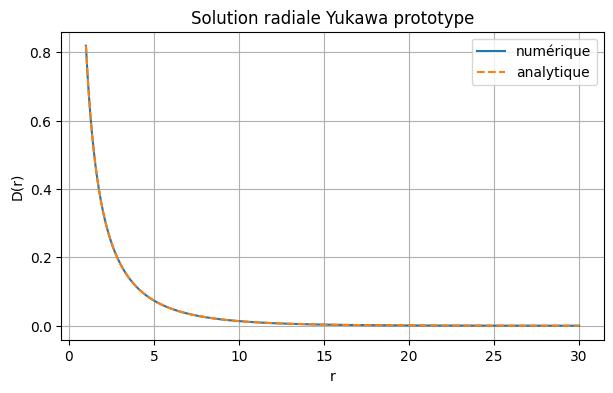

Erreur maximale : 2.8319568912138493e-12


In [20]:

def integrate_radial_field(
    r0=1.0,
    rmax=30.0,
    mass=0.2,
    charge=1.0,
    n_eval=3000
):
    def analytic(radius):
        return (
            charge
            * np.exp(-mass*radius)
            / radius
        )

    D0 = analytic(r0)

    Dprime0 = (
        -charge
        * np.exp(-mass*r0)
        * (
            mass/r0
            + 1/r0**2
        )
    )

    def rhs(radius,state):
        D_value,Dprime = state

        Dsecond = (
            mass**2*D_value
            - 2/radius*Dprime
        )

        return [
            Dprime,
            Dsecond
        ]

    radii = np.linspace(
        r0,
        rmax,
        n_eval
    )

    solution = solve_ivp(
        rhs,
        (r0,rmax),
        [D0,Dprime0],
        t_eval=radii,
        method="DOP853",
        rtol=1e-11,
        atol=1e-13
    )

    analytic_values = analytic(radii)

    return (
        solution,
        analytic_values
    )


radial_solution, radial_analytic = integrate_radial_field()

radial_error = np.max(
    np.abs(
        radial_solution.y[0]
        - radial_analytic
    )
)

plt.figure(figsize=(7,4))
plt.plot(
    radial_solution.t,
    radial_solution.y[0],
    label="numérique"
)
plt.plot(
    radial_solution.t,
    radial_analytic,
    linestyle="--",
    label="analytique"
)
plt.xlabel("r")
plt.ylabel("D(r)")
plt.title("Solution radiale Yukawa prototype")
plt.grid(True)
plt.legend()
plt.show()

print("Erreur maximale :",radial_error)



# 20. Extraction numérique des coefficients PPN

Supposons qu’une solution numérique fournisse :

\[
g_{tt}(u),
\qquad
g_{\rm space}(u).
\]

Nous ajustons :

\[
g_{tt}
=
-1+2a_1u-2a_2u^2,
\]

\[
g_{\rm space}
=
1+2b_1u+b_2u^2.
\]

Puis :

\[
\gamma=\frac{b_1}{a_1},
\qquad
\beta=\frac{a_2}{a_1^2}.
\]


In [21]:

def fit_ppn_coefficients(
    u_values,
    gtt_values,
    gspace_values
):
    u_values = np.asarray(
        u_values,
        dtype=float
    )

    gtt_values = np.asarray(
        gtt_values,
        dtype=float
    )

    gspace_values = np.asarray(
        gspace_values,
        dtype=float
    )

    def residuals(params):
        a1_value,a2_value,b1_value,b2_value = params

        gtt_model = (
            -1
            + 2*a1_value*u_values
            - 2*a2_value*u_values**2
        )

        gspace_model = (
            1
            + 2*b1_value*u_values
            + b2_value*u_values**2
        )

        return np.concatenate([
            gtt_model-gtt_values,
            gspace_model-gspace_values
        ])

    result = least_squares(
        residuals,
        x0=[
            1.0,
            1.0,
            1.0,
            1.5
        ],
        xtol=1e-14,
        ftol=1e-14,
        gtol=1e-14
    )

    a1_value,a2_value,b1_value,b2_value = result.x

    return {
        "a1":a1_value,
        "a2":a2_value,
        "b1":b1_value,
        "b2":b2_value,
        "gamma":b1_value/a1_value,
        "beta":a2_value/a1_value**2,
        "rmse":np.sqrt(
            np.mean(
                residuals(result.x)**2
            )
        )
    }


u_values = np.logspace(
    -8,
    -3,
    300
)

# Données synthétiques proches de GR.
a1_true = 1.0
a2_true = 1.0001
b1_true = 1.00002
b2_true = 1.5

gtt_synthetic = (
    -1
    + 2*a1_true*u_values
    - 2*a2_true*u_values**2
)

gspace_synthetic = (
    1
    + 2*b1_true*u_values
    + b2_true*u_values**2
)

fit_result = fit_ppn_coefficients(
    u_values,
    gtt_synthetic,
    gspace_synthetic
)

fit_result


{'a1': np.float64(1.0000000000330158),
 'a2': np.float64(1.0001000358982715),
 'b1': np.float64(1.0000199999515689),
 'b2': np.float64(1.5000000932375201),
 'gamma': np.float64(1.0000199999185524),
 'beta': np.float64(1.0001000358322332),
 'rmse': np.float64(7.062675139570134e-15)}


# 21. Pipeline de décision physique

Une future solution statique GVH devra passer les étapes suivantes :

1. vérifier l’asymptotique plate :
   \[
   A,B,C\rightarrow1;
   \]

2. retrouver la limite newtonienne :
   \[
   a_1=1;
   \]

3. extraire :
   \[
   \gamma_{\rm GVH},\beta_{\rm GVH};
   \]

4. appliquer les contraintes PPN ;

5. vérifier la régularité extérieure ;

6. calculer les observables exactes ;

7. rechercher ensuite seulement des écarts de champ fort.


In [22]:

decision_pipeline = pd.DataFrame([
    {
        "step":1,
        "test":"asymptotic flatness",
        "required_result":"A,B,C -> 1"
    },
    {
        "step":2,
        "test":"Newtonian normalization",
        "required_result":"a1 = 1"
    },
    {
        "step":3,
        "test":"PPN extraction",
        "required_result":"gamma and beta calculable"
    },
    {
        "step":4,
        "test":"Solar-System constraints",
        "required_result":"PASS"
    },
    {
        "step":5,
        "test":"exterior regularity",
        "required_result":"no unphysical singularity"
    },
    {
        "step":6,
        "test":"exact observables",
        "required_result":"Mercury, light, Shapiro"
    },
    {
        "step":7,
        "test":"strong-field novelty",
        "required_result":"falsifiable deviation"
    }
])

decision_pipeline


,step,test,required_result
0,1,asymptotic flatness,"A,B,C -> 1"
1,2,Newtonian normalization,a1 = 1
2,3,PPN extraction,gamma and beta calculable
3,4,Solar-System constraints,PASS
4,5,exterior regularity,no unphysical singularity
5,6,exact observables,"Mercury, light, Shapiro"
6,7,strong-field novelty,falsifiable deviation



# 22. Statut des résultats

## Dérivé exactement

- Schwarzschild annule \(R_{\mu\nu}\) dans le vide ;
- Schwarzschild donne :
  \[
  \gamma=\beta=1;
  \]
- pour la famille métrique paramétrée :
  \[
  \gamma=b_1/a_1,
  \qquad
  \beta=a_2/a_1^2.
  \]

## Dérivé conditionnellement

- contraintes sur \(a_2,b_1\) ;
- contraintes sur les paramètres Yukawa ;
- extraction numérique depuis une solution donnée.

## Non encore dérivé

- valeurs uniques de \(a_i,b_i\) depuis l’action fondamentale GVH ;
- charge \(Q_D\) d’une masse ;
- masse \(m_D\) du champ statique ;
- solution intérieure d’une étoile ;
- conditions de raccordement matière–vide.


In [23]:

result_status = pd.DataFrame([
    {
        "result":"Schwarzschild vacuum solution",
        "status":"DERIVED"
    },
    {
        "result":"GR PPN gamma=beta=1",
        "status":"DERIVED"
    },
    {
        "result":"gamma=b1/a1, beta=a2/a1^2",
        "status":"DERIVED FOR PARAMETRIC FAMILY"
    },
    {
        "result":"PPN bounds on coefficients",
        "status":"CONDITIONAL"
    },
    {
        "result":"unique GVH static coefficients",
        "status":"NOT YET DERIVED"
    },
    {
        "result":"Yukawa field equation",
        "status":"PROTOTYPE"
    }
])

result_status


,result,status
0,Schwarzschild vacuum solution,DERIVED
1,GR PPN gamma=beta=1,DERIVED
2,"gamma=b1/a1, beta=a2/a1^2",DERIVED FOR PARAMETRIC FAMILY
3,PPN bounds on coefficients,CONDITIONAL
4,unique GVH static coefficients,NOT YET DERIVED
5,Yukawa field equation,PROTOTYPE



# 23. Validation automatique


In [24]:

ricci_schwarzschild_ok = (
    Ricci_S == sp.zeros(4)
)

gtt_series_ok = (
    sp.expand(
        gtt_iso_series
        - (
            -1+2*u-2*u**2+sp.Rational(3,2)*u**3
        )
    ) == 0
)

gspace_series_ok = (
    sp.expand(
        B_iso_series
        - (
            1
            + 2*u
            + sp.Rational(3,2)*u**2
            + sp.Rational(1,2)*u**3
        )
    ) == 0
)

ppn_identification_ok = (
    sp.simplify(
        gamma_GVH-b1/a1
    ) == 0
    and
    sp.simplify(
        beta_GVH-a2/a1**2
    ) == 0
)

epsilon_mapping_ok = (
    sp.expand(
        Delta_gamma_eps
        - epsilon_D*(
            sigma1-alpha1
        )
    ) == 0
    and
    sp.expand(
        Delta_beta_eps
        - epsilon_D*(
            alpha2-2*alpha1
        )
    ) == 0
)

yukawa_solution_ok = (
    yukawa_residual == 0
)

radial_numeric_ok = (
    radial_error < 1e-8
)

fit_ok = (
    abs(
        fit_result["gamma"]
        - b1_true/a1_true
    ) < 1e-6
    and
    abs(
        fit_result["beta"]
        - a2_true/a1_true**2
    ) < 1e-5
)

validation_df = pd.DataFrame([
    {
        "test":"Schwarzschild Ricci vacuum",
        "status":"PASS" if ricci_schwarzschild_ok else "FAIL"
    },
    {
        "test":"Schwarzschild g_tt isotropic series",
        "status":"PASS" if gtt_series_ok else "FAIL"
    },
    {
        "test":"Schwarzschild spatial isotropic series",
        "status":"PASS" if gspace_series_ok else "FAIL"
    },
    {
        "test":"PPN coefficient identification",
        "status":"PASS" if ppn_identification_ok else "FAIL"
    },
    {
        "test":"epsilon coefficient mapping",
        "status":"PASS" if epsilon_mapping_ok else "FAIL"
    },
    {
        "test":"Yukawa analytic prototype",
        "status":"PASS" if yukawa_solution_ok else "FAIL"
    },
    {
        "test":"Yukawa numerical integration",
        "status":"PASS" if radial_numeric_ok else "CHECK"
    },
    {
        "test":"numerical PPN extraction",
        "status":"PASS" if fit_ok else "CHECK"
    }
])

validation_df


,test,status
0,Schwarzschild Ricci vacuum,PASS
1,Schwarzschild g_tt isotropic series,PASS
2,Schwarzschild spatial isotropic series,PASS
3,PPN coefficient identification,PASS
4,epsilon coefficient mapping,PASS
5,Yukawa analytic prototype,PASS
6,Yukawa numerical integration,PASS
7,numerical PPN extraction,PASS


In [25]:

overall_status = (
    "PASS-PARAMETRIC-DERIVATION"
    if (
        validation_df["status"]
        == "PASS"
    ).all()
    else "CHECK"
)

print("STATUT DU NOTEBOOK :",overall_status)
print("PRÉDICTION PPN UNIQUE DE GVH : NON ENCORE DISPONIBLE")


STATUT DU NOTEBOOK : PASS-PARAMETRIC-DERIVATION
PRÉDICTION PPN UNIQUE DE GVH : NON ENCORE DISPONIBLE



# 24. Export


In [26]:

import json

validation_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.22_Validation.csv",
    index=False
)

bounds_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.22_PPN_Bounds.csv",
    index=False
)

static_candidates.to_csv(
    "GVH_Diagonal_Cubic_0.2.22_Static_Candidates.csv",
    index=False
)

decision_pipeline.to_csv(
    "GVH_Diagonal_Cubic_0.2.22_Decision_Pipeline.csv",
    index=False
)

result_status.to_csv(
    "GVH_Diagonal_Cubic_0.2.22_Result_Status.csv",
    index=False
)

fit_export = pd.DataFrame([
    fit_result
])

fit_export.to_csv(
    "GVH_Diagonal_Cubic_0.2.22_PPN_Fit_Example.csv",
    index=False
)

metadata = {
    "notebook_status":overall_status,
    "reference_solution":"Schwarzschild",
    "reference_PPN":{
        "gamma":1.0,
        "beta":1.0
    },
    "parametric_mapping":{
        "gamma_GVH":"b1/a1",
        "beta_GVH":"a2/a1^2",
        "Delta_gamma_linear":"epsilon_D(sigma1-alpha1)",
        "Delta_beta_linear":"epsilon_D(alpha2-2alpha1)"
    },
    "pure_spatial_sector":{
        "alpha1":0,
        "alpha2":0,
        "Delta_gamma":"epsilon_D sigma1",
        "Delta_beta":0
    },
    "Yukawa_static_field":"prototype only",
    "unique_GVH_PPN_prediction":"not yet available",
    "main_open_requirement":"derive a_i and b_i from a fully specified GVH covariant action and source equations"
}

with open(
    "GVH_Diagonal_Cubic_0.2.22_Metadata.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=2,
        ensure_ascii=False
    )

print("Exports terminés.")


Exports terminés.



# 25. Conclusion scientifique

La référence de Schwarzschild donne exactement :

\[
\boxed{
\gamma_{\rm GR}=1,
\qquad
\beta_{\rm GR}=1
}.
\]

Pour la famille statique GVH :

\[
g_{tt}
=
-1+2a_1u-2a_2u^2+\cdots,
\]

\[
g_{ij}
=
\left(
1+2b_1u+b_2u^2+\cdots
\right)\delta_{ij},
\]

les paramètres PPN sont :

\[
\boxed{
\gamma_{\rm GVH}
=
\frac{b_1}{a_1}
}
\]

et :

\[
\boxed{
\beta_{\rm GVH}
=
\frac{a_2}{a_1^2}
}.
\]

À premier ordre dans un couplage directionnel :

\[
\boxed{
\gamma_{\rm GVH}-1
=
\epsilon_D
(\sigma_1-\alpha_1)
}
\]

et :

\[
\boxed{
\beta_{\rm GVH}-1
=
\epsilon_D
(\alpha_2-2\alpha_1)
}.
\]

Pour un secteur strictement spatial sans trace :

\[
\alpha_1=\alpha_2=0,
\]

donc :

\[
\boxed{
\beta_{\rm GVH}=1
}
\]

et :

\[
\boxed{
\gamma_{\rm GVH}-1
=
\epsilon_D\sigma_1
}.
\]

Le notebook a donc dérivé la correspondance complète entre une solution statique paramétrée et les tests PPN.

Mais la conclusion décisive reste :

\[
\boxed{
a_1,a_2,b_1
\text{ ne sont pas encore prédits de manière unique par GVH}
}.
\]

Pour obtenir une véritable prédiction, il faut fixer l’action covariante complète, ses couplages à la source et résoudre les équations statiques correspondantes.

---

## Étape suivante proposée

\[
\boxed{
\texttt{GVH\_Diagonal\_Cubic\_0.2.23\_Covariant\_Static\_Field\_Equations\_Source\_Matching.ipynb}
}
\]

Elle devra :

- choisir explicitement l’action covariante minimale finale ;
- introduire une source sphérique \(T_{\mu\nu}\) ;
- dériver les équations couplées pour \(A(r),B(r),D(r)\) ;
- résoudre la région intérieure et extérieure ;
- imposer le raccordement à la surface ;
- calculer \(a_1,a_2,b_1\) sans les choisir ;
- produire enfin une prédiction PPN propre au modèle.
